In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/processed'

df_train = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_train.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_test.csv'))

# Removendo a coluna 'id' que não é uma feature
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

# A feature 'service' tem alguns valores '-' que precisam ser tratados. Vamos mantê-los como uma categoria.
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

# Definindo X (features) e y (alvo)
# Nosso alvo agora é 'attack_cat' para a classificação multiclasse
X_train = df_train.drop(['attack_cat', 'label'], axis=1)
y_train = df_train['attack_cat']

X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['attack_cat']

# Inicializar o LabelEncoder
label_encoder = LabelEncoder()

# Aprender a correspondência entre texto e número usando APENAS os dados de treino
label_encoder.fit(y_train)

# Transformar os rótulos de treino e teste para o formato numérico
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Ver a correspondência criada
print("--- Mapeamento de Classes para Números ---")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"'{class_name}' -> {i}")

# Calcular pesos para as classes para lidar com o desbalanceamento
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)
print("\nPesos das amostras calculados para o treinamento.")

# Identificando colunas numéricas e categóricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Criando o pré-processador com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Mantém colunas não especificadas (se houver)
)

# Criando o pipeline final que inclui o pré-processamento e o classificador
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softprob', # Objetivo para classificação multiclasse
        n_estimators=150,           # Um pouco mais de árvores
        eval_metric='mlogloss',     # Métrica de avaliação para multiclasse
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipeline de pré-processamento e modelo criado com sucesso.")
print(f"Features numéricas ({len(numeric_features)}): {numeric_features.tolist()}")
print(f"Features categóricas ({len(categorical_features)}): {categorical_features.tolist()}")

--- Mapeamento de Classes para Números ---
'Analysis' -> 0
'Fuzzers' -> 1
'Normal' -> 2
'Reconnaissance' -> 3

Pesos das amostras calculados para o treinamento.
Pipeline de pré-processamento e modelo criado com sucesso.
Features numéricas (38): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
Features categóricas (3): ['proto', 'service', 'state']


In [3]:
print("Iniciando o treinamento do modelo XGBoost...")

# Treinando o pipeline no conjunto de dados de treino
model_pipeline.fit(X_train, y_train_encoded, classifier__sample_weight=sample_weights)

# --- EXPORTAÇÃO DO MODELO TREINADO --- #
try:
    # Define o nome do arquivo para salvar o pipeline treinado
    pipeline_filename = 'pipeline_XGB.joblib'
    joblib.dump(model_pipeline, pipeline_filename)
    print(f"Pipeline treinado salvo com sucesso como '{pipeline_filename}'")

    # Opcional: Salvar o pré-processador separadamente (se precisar usá-lo isoladamente)
    preprocessor_filename = 'preprocessor_XGB.joblib'
    joblib.dump(model_pipeline.named_steps['preprocessor'], preprocessor_filename)
    print(f"Pré-processador salvo com sucesso como '{preprocessor_filename}'")

    label_encoder_filename = 'le_XGB.joblib'
    joblib.dump(label_encoder, label_encoder_filename)
    print(f"Label encoder salvo com sucesso como '{label_encoder_filename}'")

except Exception as e:
    print(f"Erro ao salvar o modelo/pipeline: {e}")
# --- FIM DA EXPORTAÇÃO ---

print("Treinamento concluído.")

# Realizando previsões no conjunto de teste
print("Realizando previsões no conjunto de teste...")
y_pred = model_pipeline.predict(X_test)

print("Previsões concluídas.")

Iniciando o treinamento do modelo XGBoost...
Pipeline treinado salvo com sucesso como 'pipeline_XGB.joblib'
Pré-processador salvo com sucesso como 'preprocessor_XGB.joblib'
Label encoder salvo com sucesso como 'le_XGB.joblib'
Treinamento concluído.
Realizando previsões no conjunto de teste...
Previsões concluídas.


--- Relatório de Classificação Binária (Normal vs. Ataque) ---
              precision    recall  f1-score   support

  Normal (0)       0.99      0.96      0.98      2307
  Ataque (1)       0.97      0.99      0.98      2547

    accuracy                           0.98      4854
   macro avg       0.98      0.98      0.98      4854
weighted avg       0.98      0.98      0.98      4854



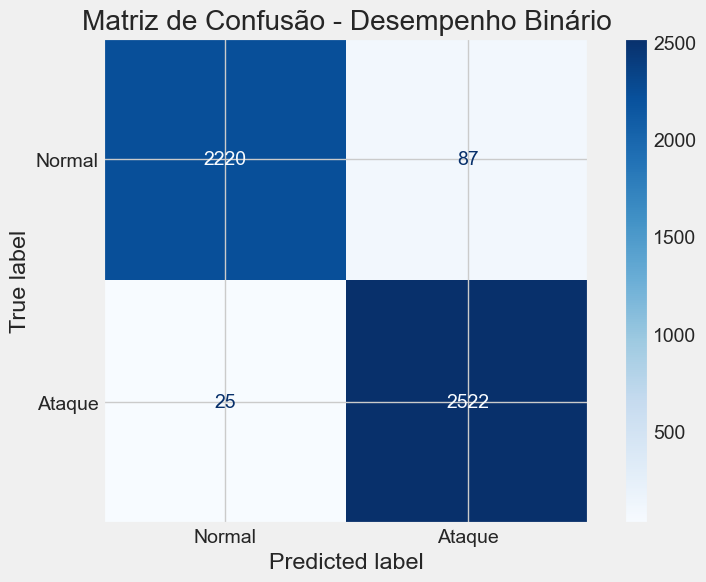

In [4]:
# Decodificar as previsões numéricas para rótulos de texto
# y_pred contém os números (ex: 5, 8, 1...), vamos convertê-los de volta para texto
y_pred_labels = label_encoder.inverse_transform(y_pred)

# Convertendo os resultados multiclasse para binário
# 0 para 'Normal', 1 para qualquer tipo de ataque
y_test_binary = np.where(y_test == 'Normal', 0, 1)
y_pred_binary = np.where(y_pred_labels == 'Normal', 0, 1)

print("--- Relatório de Classificação Binária (Normal vs. Ataque) ---")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Normal (0)', 'Ataque (1)']))

# Gerando e plotando a Matriz de Confusão Binária
cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - Desempenho Binário')
plt.savefig('confusion_matrix_multi_xgb.png') # Salva a matriz como imagem
plt.show()

--- Relatório de Classificação por Tipo de Ataque ---
                precision    recall  f1-score   support

      Analysis       0.84      0.88      0.86       416
       Fuzzers       0.93      0.97      0.95      1105
        Normal       0.99      0.96      0.98      2307
Reconnaissance       1.00      1.00      1.00      1026

      accuracy                           0.96      4854
     macro avg       0.94      0.95      0.95      4854
  weighted avg       0.96      0.96      0.96      4854



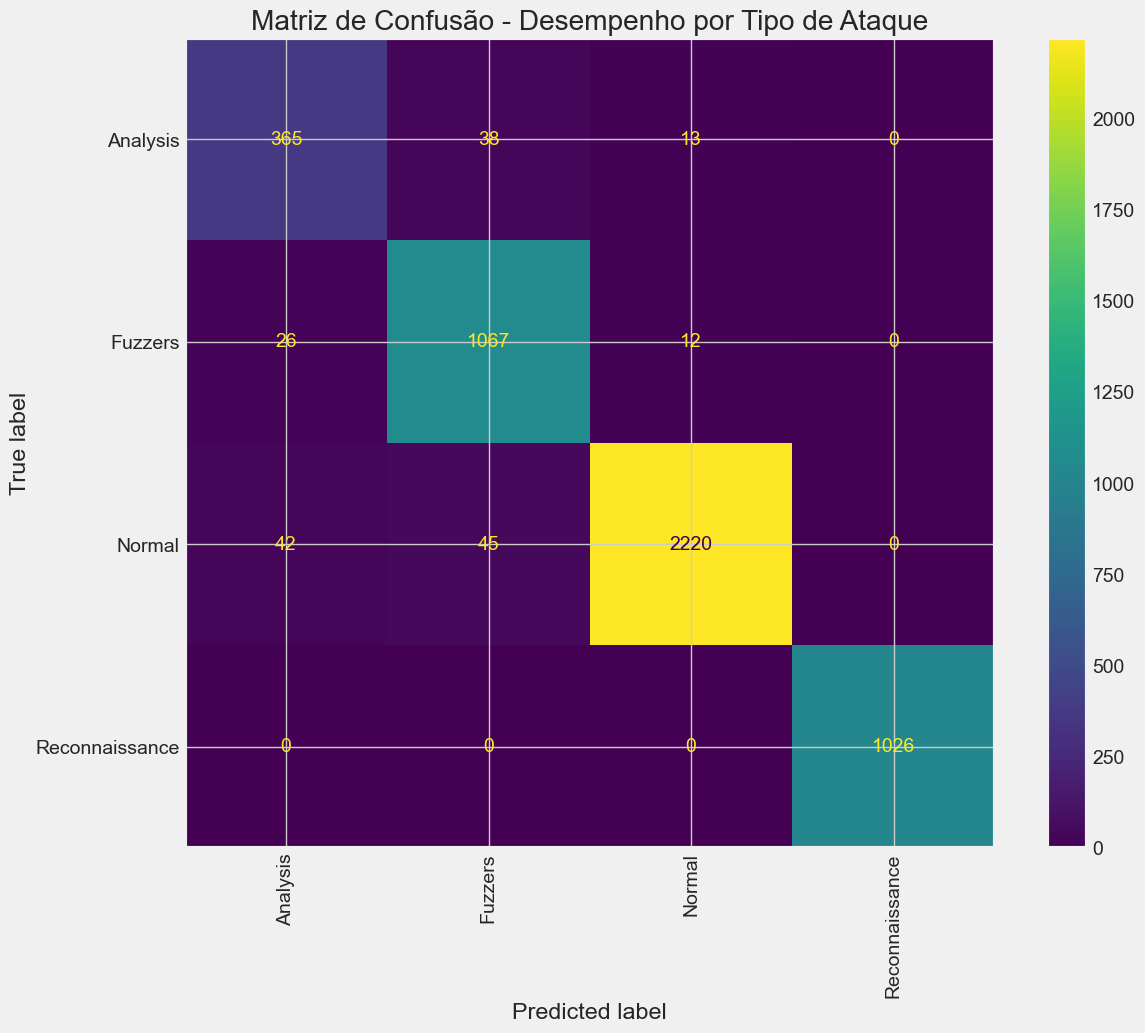

In [5]:
# Obtendo os nomes das classes na ordem correta
class_names = df_train['attack_cat'].unique()

print("--- Relatório de Classificação por Tipo de Ataque ---")
# Usando os rótulos originais multiclasse
print(classification_report(y_test, y_pred_labels))

# Matriz de Confusão Multiclasse
class_names = label_encoder.classes_
cm_multi = confusion_matrix(y_test, y_pred_labels, labels=class_names)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp_multi.plot(ax=ax, cmap='viridis', xticks_rotation='vertical')
plt.title('Matriz de Confusão - Desempenho por Tipo de Ataque')
plt.savefig('confusion_matrix_atks_multi_xgb.png') # Salva a matriz como imagem
plt.show()